In [244]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 40)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, LabelEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import pickle

In [229]:
df = pd.read_csv('hotel_bookings.csv')

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


| Attribute                     | Data Type | Description                                                                                                      |
|-------------------------------|-----------|------------------------------------------------------------------------------------------------------------------|
| hotel                         | Object    | Type of hotel (Resort Hotel or City Hotel)                                                                       |
| is_canceled                   | Integer   | Whether the booking was canceled (1) or not (0)                                                                  |
| lead_time                     | Integer   | Number of days between booking date and arrival date                                                             |
| arrival_date_year             | Integer   | Year of arrival date                                                                                             |
| arrival_date_month            | Object    | Month of arrival date                                                                                            |
| arrival_date_week_number      | Integer   | Week number of arrival date                                                                                      |
| arrival_date_day_of_month     | Integer   | Day of arrival date                                                                                              |
| stays_in_weekend_nights       | Integer   | Number of weekend nights (Saturday and Sunday)                                                                   |
| stays_in_week_nights          | Integer   | Number of week nights (Monday to Friday)                                                                         |
| adults                        | Integer   | Number of adults                                                                                                 |
| children                      | Float     | Number of children                                                                                               |
| babies                        | Integer   | Number of babies                                                                                                 |
| meal                          | Object    | Type of meal booked (BB, HB, FB, SC)                                                                             |
| country                       | Object    | Country of origin of the customer                                                                                |
| market_segment                | Object    | Market segment designation (e.g., Direct, Corporate, Online TA)                                                  |
| distribution_channel          | Object    | Booking distribution channel (e.g., Direct, TA/TO)                                                               |
| is_repeated_guest             | Integer   | Whether the customer is a repeated guest (1) or not (0)                                                          |
| previous_cancellations        | Integer   | Number of previous cancellations                                                                                 |
| previous_bookings_not_canceled| Integer   | Number of previous bookings not canceled                                                                         |
| reserved_room_type            | Object    | Code of room type reserved                                                                                       |
| assigned_room_type            | Object    | Code of room type assigned                                                                                       |
| booking_changes               | Integer   | Number of changes made to the booking                                                                            |
| deposit_type                  | Object    | Type of deposit made (No Deposit, Non Refund, Refundable)                                                        |
| agent                         | Float     | ID of the travel agency that made the booking                                                                    |
| company                       | Float     | ID of the company/entity that made the booking                                                                   |
| days_in_waiting_list          | Integer   | Number of days the booking was in the waiting list                                                               |
| customer_type                 | Object    | Type of customer (Contract, Group, Transient, Transient-Party)                                                   |
| adr                           | Float     | Average Daily Rate as defined by dividing the sum of all lodging transactions by the total number of staying nights|
| required_car_parking_spaces   | Integer   | Number of car parking spaces required                                                                            |
| total_of_special_requests     | Integer   | Total number of special requests made                                                                            |
| reservation_status            | Object    | Reservation last status (Canceled, Check-Out, No-Show)                                                           |
| reservation_status_date       | Object    | Date at which the last status was set                                                                            |


## Business Problem & Understanding

---

Bisnis perhotelan secara umum cukup sering menghadapi masalah pembatalan booking (canceled booking) yang tentunya berdampak negatif pada pendapatan dan pengelolaan sumber daya yang ada. Pembatalan booking ini dapat menyebabkan beberapa hal seperti kehilangan/pengurangan pendapatan (jika hotel memiliki ketentuan pembatalan booking yang dimana uang customer tidak direfund full 100%), pengalokasian sumber daya yang tidak efisien, dan overbooking yang berujung pada ketidakpuasan pelanggan

Pembatalan booking dari pelanggan penting untuk diminimalisir supaya bisa mengoptimalkan pendapatan, mengefisiensi operasional, dan tentunya meningkatkan kepuasana pelanggan

**Tujuan**

> Dengan adanya model machine learning yang dapat mengklasifikasikan apakah seorang pelanggan akan membatalkan bookingnya atau tidak berdasarkan karakteristik yang ada, pihak hotel juga tentunya akan lebih waspada dan memiliki rencana/strategi cadangan untuk menghadapi pelanggan yang kemungkinan akan melakukan pembatalan booking

> Model machine learning yang sudah dibuat nantinya dapat digunakan secara berkala untuk 
1. Monitoring, mengevaluasi, dan memperbarui data dari model yang sudah dibuat
2. Pada prosses reservase, untuk mengevaluasi kemungkinan pembatalan saat dilakukan booking oleh pelanggan

## EDA

---

### Data Cleaning

Fitur yang diubah dan action perubahannya

1. Fill Null
    * agent -> 0
    
    > Karena kolom agent bertipe data `int`, maka nilai null diisi dengan 0, karena dianggap tidak menggunakan agent

    * children -> 0

    > Karena kolom children bertipe data `int`, maka nilai null diisi dengan 0, karena dianggap tidak membawa anak

2. Drop
    * company
    * reservation_status_date
    * country

3. Replace
    * is_canceled
    > 0: No, 1: Yes

In [230]:
df['agent'].fillna(0, inplace = True)

df.drop(columns = ['company', 'reservation_status_date', 'country'], 
        inplace = True)

df['children'].fillna(0, inplace = True)
df['children'] = df['children'].astype(int)

df['is_canceled'].replace({0: 'No',
                           1: 'Yes'},
                          inplace = True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  object 
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  int32  
 11  babies                          119390 non-null  int64  
 12  meal            

Cek konsistensi data

In [231]:
# Check Data Consistency

df_check = df[~((df['adults'] == 0) & 
                (df['children'] == 0) & 
                (df['babies'] == 0))]

print(f'Panjang data asli : {len(df)}\nCek jumlah tamu yang cancel tapi tidak ada tamunya : {len(df_check)}\nSelisih : {len(df)-len(df_check)}')

# Replacing df after consistency check
df = df_check.copy()

Panjang data asli : 119390
Cek jumlah tamu yang cancel tapi tidak ada tamunya : 119210
Selisih : 180


Cek Data Outlier

In [232]:
num_df = df.select_dtypes(include = ['int', 'float'])
outlier_info = pd.DataFrame(columns = ['Column', 
                                       'Lower Bound', 
                                       'Upper Bound', 
                                       'Unique Values'])

outlier_records = []
for col in num_df:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_outlier = df[(df[col] <= lower_bound) & (df[col] >= upper_bound)]
    
    outlier_records.append({
        'Column': col,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Unique Values': df[col].nunique(),
        'Outlier Count' : len(df_outlier)
    })
    

outlier_info = pd.DataFrame(outlier_records).round(3).sort_values(
    by = ['Unique Values'],
    ascending = [False]
    
).reset_index(drop = True)

display(outlier_info)

,Column,Lower Bound,Upper Bound,Unique Values,Outlier Count
0,adr,-15.25,210.75,8866,0
1,lead_time,-196.50,375.50,479,0
2,agent,-210.50,369.50,334,0
3,days_in_waiting_list,0.00,0.00,127,115517
4,previous_bookings_not_canceled,0.00,0.00,73,115597
5,arrival_date_week_number,-17.00,71.00,53,0
6,stays_in_week_nights,-2.00,6.00,33,0
7,arrival_date_day_of_month,-14.50,45.50,31,0
8,booking_changes,0.00,0.00,19,101232
9,stays_in_weekend_nights,-3.00,5.00,17,0


#### Feature Engineering

Manual Feature Enginering:

1. total_stay

2. is_family

In [233]:
# Manual Feature Engineering

df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

df.drop(columns = ['stays_in_weekend_nights', 'stays_in_week_nights'], 
        inplace = True)

def determine_family_status(row):
    if (row['babies'] > 0 or row['children'] > 0 or row['adults'] > 1):
        return 1
    elif (row['adults'] == 1 and row['children'] == 0 and row['babies'] == 0):
        return 0
    # elif (row['adults'] == 0 and (row['children'] > 0 or row['babies'] > 0)):
    #     return 2
    else:
        return 2

df['is_family'] = df.apply(determine_family_status, 
                           axis = 1)
df['is_family'] = df['is_family'].astype(int)


In [283]:
temp_df = df[df.is_family == 2]

print('Run Error Check on is_family == 2 (Human Error)\n', '**'*22)
for cols in temp_df[['adults', 'children', 'babies', 'is_canceled']]:
    print(f'Unique value count in {cols}:\n{temp_df[cols].value_counts()}\n')

Run Error Check on is_family == 2 (Human Error)
 ********************************************
Unique value count in adults:
Series([], Name: count, dtype: int64)

Unique value count in children:
Series([], Name: count, dtype: int64)

Unique value count in babies:
Series([], Name: count, dtype: int64)

Unique value count in is_canceled:
Series([], Name: count, dtype: int64)



Di error checking ini, tidak ada data error yang ditemukan (`is_family == 2`), sehingga kita bisa lanjut ke proses berikutnya

In [246]:
X = df.drop(columns = ['is_canceled'])
y = df['is_canceled']

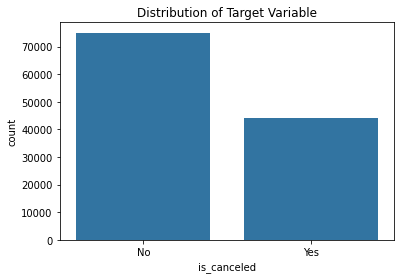

In [247]:
sns.countplot(x = y)
plt.title('Distribution of Target Variable')
plt.show()

Auto Feature Engineering (using package/methods)

Independen Variabel yang ada pada `X` dibagi menjadi 4 tipe data
1. Fitur kategorikal dengan jumlah data unik banyak (>= 10) / **kategorikal nominal** -> `high_cardinality_cols`

2. Fitur kategorikal dengan jumlah data unik banyak (< 10) / **kategorikal ordinal** -> `low_cardinality_cols`

3. Fitur numerik dengan jumlah data unik banyak (>= 40) -> `continuous_numeric_cols`

4. Fitur numerik dengan jumlah data unik sedikit (< 40) -> passthrough

Dan digunakan 3 package untuk melakukan Feature Engineering
1. `LabelEncoder()` -> digunakan untuk mengubah kolom yang bertipe data object menjadi angka, jika kolom tersebut bersifat kategorikal nominal (tidak ada tingkatannya) atau memiliki data unik yang banyak didalamnya

2. `StandardScaler()` -> digunakan untuk menskalakan data numerik, biasanya cocok digunakan untuk data kontinu, tapi bisa juga untuk data diskrit yang memiliki jumlah data unik yang tinggi

3. `OneHotEncoder()` -> digunakan untuk mengubah kolom yang bertipe data object menjadi satu atau lebih kolom biner tergantung berapa jumlah value unik di fitur tersebut (value_unik * 2)

In [248]:
categorical_X = X.select_dtypes(include = ['object'])
numeric_X = X.select_dtypes(include = ['int', 'float'])

high_cardinality_cols = [col for col in categorical_X.columns if X[col].nunique() >= 10]
low_cardinality_cols = [col for col in categorical_X.columns if X[col].nunique() < 10]
continuous_numeric_cols = [col for col in numeric_X.columns if X[col].nunique() >= 500]

# Label Encoding for high count of unique categorical data
for col in high_cardinality_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    
preprocessor = ColumnTransformer(
    transformers = [
        ('num', MinMaxScaler(), continuous_numeric_cols),
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), low_cardinality_cols)
    ],
    
    # This keeps the label encoded columns in the data
    remainder = 'passthrough'  
)

#### Feature Selection

Seleksi fitur dilakukan dengan menggunakan `SelectKBest` yang melakukan seleksi dengan cara memberikan nilai/score kepada fitur yang ada menggunakan fungsi statistik yang dipilih, kemudian mengambil sejumlah fitur terbaik berdasarkan jumlah parameter `k`

Fungsi statistik yang digunakan disini `f_classif`, yang menghitung nilai ANOVA F-Value untuk setiap fitur yang mengukur rasio variabilitas antar fitur

In [249]:
feature_selection = SelectKBest(score_func = f_classif, 
                                k = 30)

## Analytics

---

#### Algorithm

> #### **Logistic Regression (Lr)**


1. Cara Kerja

Lr `LogisticRegression()` Adalah algoritma machine learning untuk melakukan klasifikasi data yang digunakan untuk memprediksi besaran probabilitas kejadian dari variabel biner, yang dimana model ini menghitung probabilitas sebuah kejadian menggunakan fungsi logistik dan bekerja dengan mengestimasi koefisien regresi dan input dari fitur untuk meminimalkan kesalahan dalam memprediksi probabilitas kejadian target

Secara teknis, LogisticRegression bekerja mirip seperti model regresi lainnya, yaitu dengan cara melakukan fitting menggunakan `.fit()` dengan parameter variabel independen dan variabel dependen/targetnya

2. Limitasi Model

    a. Asumsi Linearitas pada Log Odds

    > Logistic Regression mengasumsikan bahwa ada hubungan linear antara fitur independen dan log odds dari output. Jika data sebenarnya tidak memiliki hubungan linear ini, maka model tidak akan mampu menangkap pola dengan baik, dan performanya akan menurun.

    b. Multikolinearitas

    > Multikolinearitas terjadi ketika dua atau lebih fitur independen sangat berkorelasi satu sama lain. Ini dapat menyebabkan koefisien yang tidak stabil dan interpretasi yang salah. Dalam kasus yang ekstrem, ini bisa membuat model tidak mampu menentukan fitur mana yang sebenarnya penting.

    c. Outliers

    > Logistic Regression sangat sensitif terhadap outliers. Outliers dapat mendistorsi keputusan model dan menyebabkan hasil yang tidak akurat. Oleh karena itu, penting untuk mendeteksi dan menangani outliers dalam data sebelum melakukan pelatihan model.

    d. Imbalanced Dataset

    > Jika dataset tidak seimbang, di mana satu kelas jauh lebih banyak daripada kelas lainnya, model cenderung memprediksi kelas mayoritas dengan lebih sering, mengabaikan kelas minoritas. Ini bisa mengakibatkan model yang bias dan performa yang buruk pada kelas minoritas.

    e. Feature Scalling

    > Fitur dengan skala yang sangat berbeda dapat menyebabkan model Logistic Regression tidak bekerja dengan baik. Oleh karena itu, penting untuk melakukan scaling pada fitur sebelum pelatihan model.

3. Proses Teknis

    a. Split data menjadi train and test dengan perbandingan 8:2 `train_test_split`

    b. Menggunakan package untuk mengotomatisasi urutan alur kerja pemodelan machine learning menggunakan `Pipeline()` yang memungkinkan untuk menggabungkan preprocessing data dan pelatihan model menjadi satu kesatuan, serta bisa menghindari adanya **data leakage**

    c. Melakukan Hyperparameter tuning dengan menggunakan `GridSearchCV()` dengan tujuan untuk menemukan kombinasi hyperparameter terbaik berdasarkan kombinasi hyperparameter yang terlah ditentukan pada `param_grid`. Function ini juga telah terintegrasi dengan fungsi validasi silang / cross validation yang membagi lagi data yang di inputkan (misal data train) menjadi train dan validation tergantung jumlah `cv` yang diinput

In [250]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    train_size = 0.8, 
                                                    random_state = 1000)

# Logistic Regression Model
model_lr = LogisticRegression(random_state = 1000)

In [251]:
# Pipeline

pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('feature_selection', feature_selection),
    ('classifier', model_lr)
])

# GridSearchCV
param_grid = {
    'feature_selection__k': [10, 20, 30],  
    'classifier__C': [0.01, 0.1, 1, 10],  
    'classifier__solver': ['liblinear']  
}

grid_search = GridSearchCV(pipeline, 
                           param_grid, 
                           cv = 5, 
                           scoring = 'accuracy', 
                           n_jobs = -1)

In [252]:
import statsmodels.api as sm

logit_model = sm.Logit(y_train, sm.add_constant(X_train))
result = logit_model.fit()

# Plot residuals
plt.scatter(result.fittedvalues, result.resid_response)
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [ ]:
import numpy as np
from scipy.stats import zscore

# Menggunakan Z-score
z_scores = np.abs(zscore(X_train))
outliers = (z_scores > 3).any(axis=1)
print("Number of outliers detected:", np.sum(outliers))

# Menggunakan boxplot
X_train.boxplot(rot=90)
plt.show()

TypeError: unsupported operand type(s) for /: 'str' and 'int'

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Menghitung VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]

print(vif_data)

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [253]:
# Fitting
grid_search.fit(X_train, y_train)

print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best Score: {grid_search.best_score_}')

Best Parameters: {'classifier__C': 0.01, 'classifier__solver': 'liblinear', 'feature_selection__k': 20}
Best Score: 1.0


In [254]:
# Export model using pickle
with open('BenjaminNikholas_LogisticRegresion_ML Model_Capstone 3.pkl', 'wb') as file:
    pickle.dump(grid_search, file)

print("Model saved succesfully!")

Model saved succesfully!


In [255]:
best_pipeline = grid_search.best_estimator_

selected_features_mask = best_pipeline.named_steps['feature_selection'].get_support()

feature_names_after_preprocessing = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

selected_feature_names = feature_names_after_preprocessing[selected_features_mask]
print(selected_feature_names)

['cat__hotel_City Hotel' 'cat__hotel_Resort Hotel'
 'cat__market_segment_Direct' 'cat__market_segment_Groups'
 'cat__distribution_channel_Direct' 'cat__distribution_channel_TA/TO'
 'cat__deposit_type_No Deposit' 'cat__deposit_type_Non Refund'
 'cat__customer_type_Transient' 'cat__customer_type_Transient-Party'
 'cat__reservation_status_Canceled' 'cat__reservation_status_Check-Out'
 'cat__reservation_status_No-Show' 'remainder__lead_time'
 'remainder__is_repeated_guest' 'remainder__previous_cancellations'
 'remainder__assigned_room_type' 'remainder__booking_changes'
 'remainder__required_car_parking_spaces'
 'remainder__total_of_special_requests']


<Axes: xlabel='Feature', ylabel='Feature'>

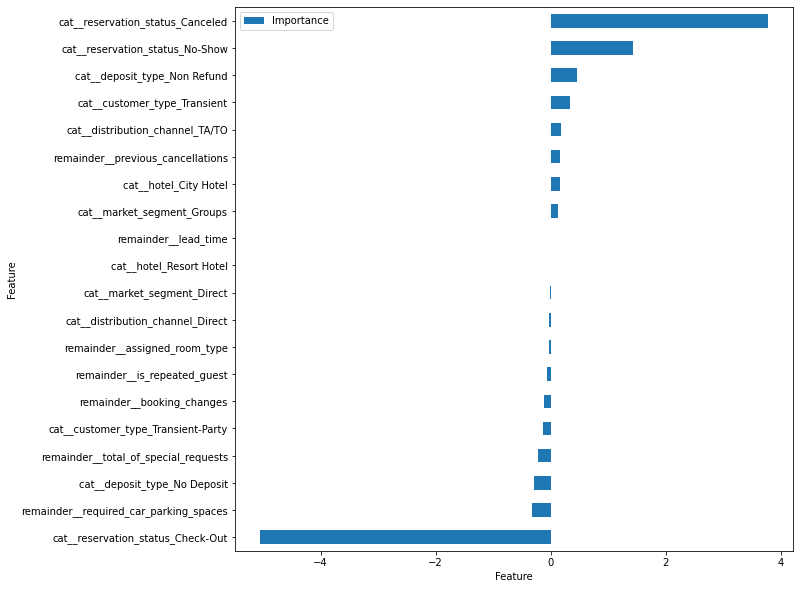

In [278]:
# selected_features_mask = best_pipeline.named_steps['preprocessor'].get_support()

# feature_names_after_preprocessing = preprocessor.get_feature_names_out()

# selected_feature_names = feature_names_after_preprocessing[selected_features_mask]

best_pipeline = grid_search.best_estimator_

best_logistic_regression = best_pipeline.named_steps['classifier']

coefficients = best_logistic_regression.coef_[0]

selected_features_mask = best_pipeline.named_steps['feature_selection'].get_support()

feature_names_after_preprocessing = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

selected_feature_names = feature_names_after_preprocessing[selected_features_mask]

feature_importance = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': coefficients.round(3)
}).sort_values(
    by = 'Importance', 
    ascending = True
).reset_index(drop = True).set_index(
    'Feature'
)

# Menampilkan fitur-fitur berdasarkan pentingnya
# display(feature_importance)

feature_importance.plot(kind = 'barh', 
                        xlabel = 'Feature',
                        figsize = (10, 10))


In [279]:
# Predictions
train_pred = grid_search.predict(X_train)
test_pred = grid_search.predict(X_test)

#### Evaluation Metrics

Metrik Evaluasi yang digunakan

1. Accuracy

> a. Dapat memberikan gambaran umum tentang seberapa sering model memprediksi dengan benar. Ini berguna saat kelas target seimbang, tetapi mungkin tidak cukup informatif jika ada ketidakseimbangan kelas yang signifikan.

> b. Dipilih karena memberikan gambaran umum tentang kinerja model secara keseluruhan. Namun, akurasi mungkin tidak cukup jika data tidak seimbang, sehingga metrik lain juga diperlukan.

2. Precision

> a. Digunakan untuk menunjukkan seberapa banyak dari prediksi pembatalan yang sebenarnya adalah pembatalan.

> b. Dipilih untuk memberikan wawasan yang lebih mendalam tentang performa model, terutama dalam situasi di mana biaya kesalahan tipe I dan tipe II berbeda. Untuk hotel, presisi membantu menghindari konfirmasi yang salah dari pembatalan, sementara recall membantu mengidentifikasi sebanyak mungkin pembatalan yang sebenarnya.

3. Recall

> a. Digunakan untuk menunjukkan seberapa banyak dari semua pembatalan yang dapat diprediksi oleh model.

> b. Dipilih karena dapat mengukur proporsi aktual positif yang benar-benar terdeteksi oleh model. Ini penting ketika biaya kesalahan negatif (False Negatives) tinggi, seperti jika tidak menangani pembatalan yang benar-benar terjadi dapat menyebabkan kerugian finansial. Recall memastikan model tidak melewatkan banyak kasus pembatalan yang sebenarnya.

4. F1-score

> a. Memberikan ukuran keseimbangan antara presisi dan recall. Ini sangat berguna saat ada ketidakseimbangan kelas, memberikan gambaran yang lebih seimbang tentang kinerja model.

> b. Dipilih untuk mempertahankan keseimbangan antara false positives dan false negatives, yang sering terjadi dalam masalah klasifikasi dengan konsekuensi signifikan dari kedua jenis kesalahan. F1 Score memberikan gambaran menyeluruh tentang kinerja model dalam konteks ini.

In [281]:
# Evaluation on train data
train_accuracy = accuracy_score(y_train, train_pred)
train_precision = precision_score(y_train, train_pred, 
                                  pos_label = 'Yes')
train_recall = recall_score(y_train, train_pred, 
                            pos_label = 'Yes')
train_f1 = f1_score(y_train, train_pred, 
                    pos_label = 'Yes')

# Evaluation on test data
test_accuracy = accuracy_score(y_test, test_pred)
test_precision = precision_score(y_test, test_pred, 
                                 pos_label = 'Yes')
test_recall = recall_score(y_test, test_pred, 
                           pos_label = 'Yes')
test_f1 = f1_score(y_test, test_pred, 
                   pos_label = 'Yes')

# Creating the DataFrame
evaluation_metrics = {
    'Accuracy': [train_accuracy, test_accuracy],
    'Precision': [train_precision, test_precision],
    'Recall': [train_recall, test_recall],
    'F1 Score': [train_f1, test_f1]
}

evaluation_df = pd.DataFrame(evaluation_metrics, 
                             index = ['Train', 'Test']).T
display(evaluation_df)


,Train,Test
Accuracy,1.0,1.0
Precision,1.0,1.0
Recall,1.0,1.0
F1 Score,1.0,1.0


In [282]:
df_sample = X.copy()
df_sample['is_canceled'] = y

for i in range(10):
    testing_data = df_sample.sample(5000)
    X_testing = testing_data.drop(columns = 'is_canceled')
    y_testing = testing_data['is_canceled']
    
    sample_pred = grid_search.predict(X_testing)
    
    temp_accuracy = accuracy_score(y_testing, sample_pred)
    temp_precision = precision_score(y_testing, sample_pred, 
                                     pos_label = 'Yes')
    temp_recall = recall_score(y_testing, sample_pred, 
                               pos_label = 'Yes')
    temp_f1 = f1_score(y_testing, sample_pred, 
                       pos_label = 'Yes')
    print(f'''Evaluation result on iteration-{i+1} ->
    accuracy {temp_accuracy} precision {temp_precision} recall {temp_recall}\n''')

Evaluation result on iteration-1 ->
    accuracy 1.0 precision 1.0 recall 1.0

Evaluation result on iteration-2 ->
    accuracy 1.0 precision 1.0 recall 1.0

Evaluation result on iteration-3 ->
    accuracy 1.0 precision 1.0 recall 1.0

Evaluation result on iteration-4 ->
    accuracy 1.0 precision 1.0 recall 1.0

Evaluation result on iteration-5 ->
    accuracy 1.0 precision 1.0 recall 1.0

Evaluation result on iteration-6 ->
    accuracy 1.0 precision 1.0 recall 1.0

Evaluation result on iteration-7 ->
    accuracy 1.0 precision 1.0 recall 1.0

Evaluation result on iteration-8 ->
    accuracy 1.0 precision 1.0 recall 1.0

Evaluation result on iteration-9 ->
    accuracy 1.0 precision 1.0 recall 1.0

Evaluation result on iteration-10 ->
    accuracy 1.0 precision 1.0 recall 1.0



## Conclusion & Recommendation

---

1. Konklusi

Berdasarkan hasil analisis yang dilakukan pada dataset pemesanan hotel dengan fitur target `is_canceled` untuk pengklasifikasian, dapat ditarik beberapa kesimpulan berikut:
> Model Klasifikasi yang diterapkan (Logisti Regression) menunjukan performa yang luar biasa pada hasil metrik evaluasi yang ada (accuracy, precision, recall, dan f1-score) pada data train maupun data test, dan juga bahkan pada saat data diuji dengan menggunakan sample yang berbeda. Hasil evaluasi ini menunjukan bahwa model yang dibangun dapat digunakan dengan sempurna untuk memprediksi pembatalan booking kedepannya, selama tidak terjadi adanya penyimpangan

2. Rekomendasi Model (kapan model baik digunakan dan sebaliknya)

> **Model baik** digunakan pada saat mengurus pemesanan/booking yang memiliki kemungkinan cancel tinggi, secara umum misalnya pada saat ada pemesanan booking kamar saat musim libur atau periode sibuk

> **Model kurang baik** digunakan saat data yang diinput tidak mencakup yang terbaru atau relevan, sehingga ada kemungkinan model memberikan hasil yang menyimpang, atau jika adanya perubahan tren yang signifikan

3. Dampak implementasi solusi terhadap proses bisnis

> Peningkatan pendapatan : Dengan mengurangi tingkat pembatalan dan memprediksi kemungkinan pembatalan, hotel dapat menjaga tingkat hunian dan memaksimalkan pendapatan. Hal ini berpotensi meningkatkan profitabilitas dan stabilitas finansial hotel.

> Efisiensi Operasional: Model dapat membantu dalam mengalokasikan sumber daya hotel secara lebih efisien. Misalnya, staf dapat diatur lebih baik dan fasilitas dapat dioptimalkan berdasarkan prediksi jumlah tamu yang akan datang dan jumlah cancel dari tamu yang melakukan pemesanan.

